# One-Dimensional Simulation

We compare several oracle and empirical Bayes denoising methods on a simulated univariate data set, reporting Monte Carlo approximations of their denoising and deconvolution errors as the likelihood and prior variances vary. This reproduces the corresponding one-dimensional simulation figure in the paper (see the figure-mapping table in the README).

In [1]:
from npeb.GLMixture import *
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import itertools
import scipy.stats as stats
from scipy.linalg import sqrtm, inv
from scipy.spatial import distance_matrix
import ot

/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
plt.rcParams.update({'font.size': 22,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

## Set up

We sample the latent variables $\Theta_1,\ldots,\Theta_n$ from a two-component Gaussian mixture $G$ on $\mathbb{R}$, with component centers $c_1 = -\sqrt{2}$ and $c_2 = \sqrt{2}$ and common component variance $\tau^2$. Conditionally on the latent variables, the observations $Z_1,\ldots,Z_n$ are drawn from a Gaussian likelihood with variance $\sigma^2$. We then sweep over a range of likelihood variances $\sigma^2$ (with $\tau^2$ fixed) and, separately, over a range of component variances $\tau^2$ (with $\sigma^2$ fixed), reporting denoising and deconvolution errors averaged over `B` Monte Carlo replications.

In [3]:
n = 500
B = 30
center1 = -np.sqrt(2)
center2 = np.sqrt(2)
tau2_base = 0.1
sigma2s = np.linspace(1e-2,2.0,num=10)

sigma2_base = 1.0
tau2s = np.linspace(1e-2,0.2,num=10)


k = 200

np.random.seed(54321)

In [4]:
centers = np.vstack([center1,center2])

def sample_latent(nsamples,var):
    classes = np.random.randint(0,2,size=(nsamples,1))
    Theta = np.random.normal(classes*center1 + (1-classes)*center2,np.sqrt(var))
    return Theta

In [5]:
denoisers = ['MLE', 'OB', 'EB', 'OVCB', 'EVCB', 'ODCB', 'EDCB']
colors = ['black', 'C0', 'C0', 'C1', 'C1', 'C2', 'C2']
styles = ['solid', 'solid', 'dashed', 'solid', 'dashed', 'solid', 'dashed']

def reduce(at, wt, eps):
    at_ = at[wt > eps]
    wt_ = wt[wt > eps]
    return at_, wt_/np.sum(wt_)

def denoising_err(delta_vals, theta):
    return np.mean(np.square(delta_vals-theta))

def deconvolution_err(delta_vals, at, wt):
    return ot.emd2([], wt, ot.dist(delta_vals, at), numItermax=1e6)

In [6]:
Eta = np.linspace(-2, 2, k).reshape(-1, 1)
rv1 = stats.norm(loc=center1, scale=np.sqrt(tau2_base))
rv2 = stats.norm(loc=center2, scale=np.sqrt(tau2_base))
G_wt = rv1.pdf(Eta).flatten() + rv2.pdf(Eta).flatten()
G_wt = G_wt/np.sum(G_wt)
Eta_, G_wt_ = reduce(Eta, G_wt, 1e-5)

## Fixed $\tau^2$, varying $\sigma^2$

Holding the component variance $\tau^2$ fixed, we sweep the likelihood variance $\sigma^2$ and record the denoising and deconvolution error of each method across replications.

In [7]:
# NOTE: One of the two longest-running cells. This sigma^2 sweep, together with the
# tau^2 sweep below, dominates the ~15 min runtime (see the README).
risks_sigma2 = np.zeros((len(denoisers),B,len(sigma2s)))
dists_sigma2 = np.zeros((len(denoisers)+1,B,len(sigma2s)))

for s in range(len(sigma2s)):

    sigma2 = sigma2s[s]
    print('sigma2=%1.3f' % sigma2, end=': ')

    for b in range(B):
        print(b, end=' ')
        Theta =  sample_latent(n,tau2_base)
        prec = np.ones_like(Theta)/sigma2
        prec_smooth = 1./(1./prec + tau2_base)
        Z = np.random.normal(Theta,np.sqrt(sigma2))
        L = np.max(Z)

        # MLE
        risks_sigma2[0, b, s] = denoising_err(Z, Theta)
        dists_sigma2[0, b, s] = deconvolution_err(Z, Eta_, G_wt_)

        # oracle Bayes
        ob_model = GLMixture(prec_type='diagonal')
        n_supp = 10000
        supp = sample_latent(n_supp,tau2_base).reshape(-1,1)
        ob_model.set_params(atoms=supp, weights=np.ones(n_supp)/n_supp)
        ob = ob_model.posterior_mean(Z.reshape(-1,1), prec)
        risks_sigma2[1, b, s] = denoising_err(ob, Theta)
        dists_sigma2[1, b, s] = deconvolution_err(ob, Eta_, G_wt_)

        # empirical Bayes
        eb_model = GLMixture(prec_type='diagonal')
        try:
            eb_model.fit(Z, 1./(tau2_base + 1./prec))
        except:
            print('-', end='')
            risks_sigma2[:, b, s] = np.nan
            dists_sigma2[:, b, s] = np.nan
            continue

        eb_post_means = eb_model.posterior_mean(Z, 1./(1./prec + tau2_base))
        eb = tau2_base * Z / (tau2_base + 1./prec) + (1./prec) * eb_post_means / (tau2_base + 1./prec)
        risks_sigma2[2, b, s] = denoising_err(eb, Theta)
        dists_sigma2[2, b, s] = deconvolution_err(eb, Eta_, G_wt_)

        transport = np.std(Theta)/np.std(ob)
        ovcb = ob*transport
        risks_sigma2[3, b, s] = denoising_err(ovcb, Theta)
        dists_sigma2[3, b, s] = deconvolution_err(ovcb, Eta_, G_wt_)

        # empirical VCB
        mu_hat = np.mean(Z)
        transport_hat = np.sqrt(np.var(Z) - sigma2)/np.std(eb)
        evcb = (eb - mu_hat)*transport_hat + mu_hat
        risks_sigma2[4, b, s] = denoising_err(evcb, Theta)
        dists_sigma2[4, b, s] = deconvolution_err(evcb, Eta_, G_wt_)

        # oracle DCB
        pi = ot.emd(np.ones(n)/n, G_wt_, ot.dist(ob, Eta_), numItermax=1e6)
        odcb = np.zeros((n,1))
        for i in range(n):
            odcb[i,:] = (pi[i,:].reshape(1,-1)@Eta_)/np.sum(pi[i,:])
        risks_sigma2[5, b, s] = denoising_err(odcb, Theta)
        dists_sigma2[5, b, s] = deconvolution_err(odcb, Eta_, G_wt_)

        # empirical DCB
        at, wt = eb_model.get_params()
        m = len(wt)
        Ghat_wt = np.zeros(k)
        for i in range(m):
            rv = stats.norm(loc=at[i,0], scale=np.sqrt(tau2_base))
            probs = rv.pdf(Eta).flatten()
            Ghat_wt += probs * wt[i] / np.sum(probs)
        Ghat_wt = Ghat_wt/np.sum(Ghat_wt)
        Eta_hat_, Ghat_wt_ = reduce(Eta, Ghat_wt, 1e-5)
        pi = ot.emd(np.ones(n)/n, Ghat_wt_, ot.dist(eb, Eta_hat_), numItermax=1e6)
        edcb = np.zeros((n,1))
        for i in range(n):
            edcb[i,:] = (pi[i,:].reshape(1,-1)@Eta_hat_)/np.sum(pi[i,:])
        risks_sigma2[6, b, s] = denoising_err(edcb, Theta)
        dists_sigma2[6, b, s] = deconvolution_err(edcb, Eta_, G_wt_)

        # deconvolution
        dists_sigma2[7, b, s] = ot.emd2(Ghat_wt_, G_wt_, ot.dist(Eta_hat_, Eta_), numItermax=1e6)

    print()

sigma2=0.010: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
sigma2=0.231: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
sigma2=0.452: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
sigma2=0.673: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
sigma2=0.894: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
sigma2=1.116: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
sigma2=1.337: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
sigma2=1.558: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
sigma2=1.779: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
sigma2=2.000: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 


## Fixed $\sigma^2$, varying $\tau^2$

Holding the likelihood variance $\sigma^2$ fixed, we sweep the component variance $\tau^2$ and again record the denoising and deconvolution error of each method.

In [8]:
# NOTE: One of the two longest-running cells. This tau^2 sweep, together with the
# sigma^2 sweep above, dominates the ~15 min runtime (see the README).
risks_tau2 = np.zeros((len(denoisers),B,len(tau2s)))
dists_tau2 = np.zeros((len(denoisers)+1,B,len(tau2s)))

for t in range(len(tau2s)):

    tau2 = tau2s[t]
    print('tau2=%1.3f' % tau2, end=': ')

    rv1 = stats.norm(loc=center1, scale=np.sqrt(tau2))
    rv2 = stats.norm(loc=center2, scale=np.sqrt(tau2))
    G_wt = rv1.pdf(Eta).flatten() + rv2.pdf(Eta).flatten()
    G_wt = G_wt/np.sum(G_wt)
    Eta_, G_wt_ = reduce(Eta, G_wt, 1e-5)

    for b in range(B):
        print(b, end=' ')
        Theta =  sample_latent(n,tau2)
        prec = np.ones_like(Theta)/sigma2_base
        prec_smooth = 1./(1./prec + tau2)
        Z = np.random.normal(Theta,np.sqrt(sigma2_base))
        L = np.max(Z)

        # MLE
        risks_tau2[0, b, t] = denoising_err(Z, Theta)
        dists_tau2[0, b, t] = deconvolution_err(Z, Eta_, G_wt_)

        # oracle Bayes
        ob_model = GLMixture(prec_type='diagonal')
        n_supp = 10000
        supp = sample_latent(n_supp,tau2).reshape(-1,1)
        ob_model.set_params(atoms=supp, weights=np.ones(n_supp)/n_supp)
        ob = ob_model.posterior_mean(Z.reshape(-1,1), prec)
        risks_tau2[1, b, t] = denoising_err(ob, Theta)
        dists_tau2[1, b, t] = deconvolution_err(ob, Eta_, G_wt_)

        # empirical Bayes
        eb_model = GLMixture(prec_type='diagonal')
        try:
            eb_model.fit(Z, 1./(tau2 + 1./prec))
        except:
            print('-', end='')
            risks_tau2[:, b, t] = np.nan
            dists_tau2[:, b, t] = np.nan
            continue

        eb_post_means = eb_model.posterior_mean(Z, 1./(1./prec + tau2))
        eb = tau2 * Z / (tau2 + 1./prec) + (1./prec) * eb_post_means / (tau2 + 1./prec)
        risks_tau2[2, b, t] = denoising_err(eb, Theta)
        dists_tau2[2, b, t] = deconvolution_err(eb, Eta_, G_wt_)

        transport = np.std(Theta)/np.std(ob)
        ovcb = ob*transport
        risks_tau2[3, b, t] = denoising_err(ovcb, Theta)
        dists_tau2[3, b, t] = deconvolution_err(ovcb, Eta_, G_wt_)

        # empirical VCB
        mu_hat = np.mean(Z)
        transport_hat = np.sqrt(np.var(Z) - sigma2_base)/np.std(eb)
        evcb = (eb - mu_hat)*transport_hat + mu_hat
        risks_tau2[4, b, t] = denoising_err(evcb, Theta)
        dists_tau2[4, b, t] = deconvolution_err(evcb, Eta_, G_wt_)

        # oracle DCB
        pi = ot.emd(np.ones(n)/n, G_wt_, ot.dist(ob, Eta_), numItermax=1e6)
        odcb = np.zeros((n,1))
        for i in range(n):
            odcb[i,:] = (pi[i,:].reshape(1,-1)@Eta_)/np.sum(pi[i,:])
        risks_tau2[5, b, t] = denoising_err(odcb, Theta)
        dists_tau2[5, b, t] = deconvolution_err(odcb, Eta_, G_wt_)

        # empirical DCB
        at, wt = eb_model.get_params()
        m = len(wt)
        Ghat_wt = np.zeros(k)
        for i in range(m):
            rv = stats.norm(loc=at[i,0], scale=np.sqrt(tau2))
            probs = rv.pdf(Eta).flatten()
            Ghat_wt += probs * wt[i] / np.sum(probs)
        Ghat_wt = Ghat_wt/np.sum(Ghat_wt)
        Eta_hat_, Ghat_wt_ = reduce(Eta, Ghat_wt, 1e-5)
        pi = ot.emd(np.ones(n)/n, Ghat_wt_, ot.dist(eb, Eta_hat_), numItermax=1e6)
        edcb = np.zeros((n,1))
        for i in range(n):
            edcb[i,:] = (pi[i,:].reshape(1,-1)@Eta_hat_)/np.sum(pi[i,:])
        risks_tau2[6, b, t] = denoising_err(edcb, Theta)
        dists_tau2[6, b, t] = deconvolution_err(edcb, Eta_, G_wt_)

        # deconvolution
        dists_tau2[7, b, t] = ot.emd2(Ghat_wt_, G_wt_, ot.dist(Eta_hat_, Eta_), numItermax=1e6)

    print()

tau2=0.010: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
tau2=0.031: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
tau2=0.052: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
tau2=0.073: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
tau2=0.094: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
tau2=0.116: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
tau2=0.137: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
tau2=0.158: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
tau2=0.179: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 
tau2=0.200: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 


## Plot risks and distances

Finally, we plot the mean denoising error and deconvolution error for each method as a function of $\sigma^2$ (left) and $\tau^2$ (right).

In [9]:
risks_sigma2[5,:,0] = 0

risks_sigma2_mean = np.nanmean(risks_sigma2,axis=1)
risks_sigma2_std = np.nanstd(risks_sigma2,axis=1)

dists_sigma2_mean = np.nanmean(dists_sigma2,axis=1)
dists_sigma2_std = np.nanstd(dists_sigma2,axis=1)

# risks_tau2[5,:,0] = 0

risks_tau2_mean = np.nanmean(risks_tau2,axis=1)
risks_tau2_std = np.nanstd(risks_tau2,axis=1)

dists_tau2_mean = np.nanmean(dists_tau2,axis=1)
dists_tau2_std = np.nanstd(dists_tau2,axis=1)

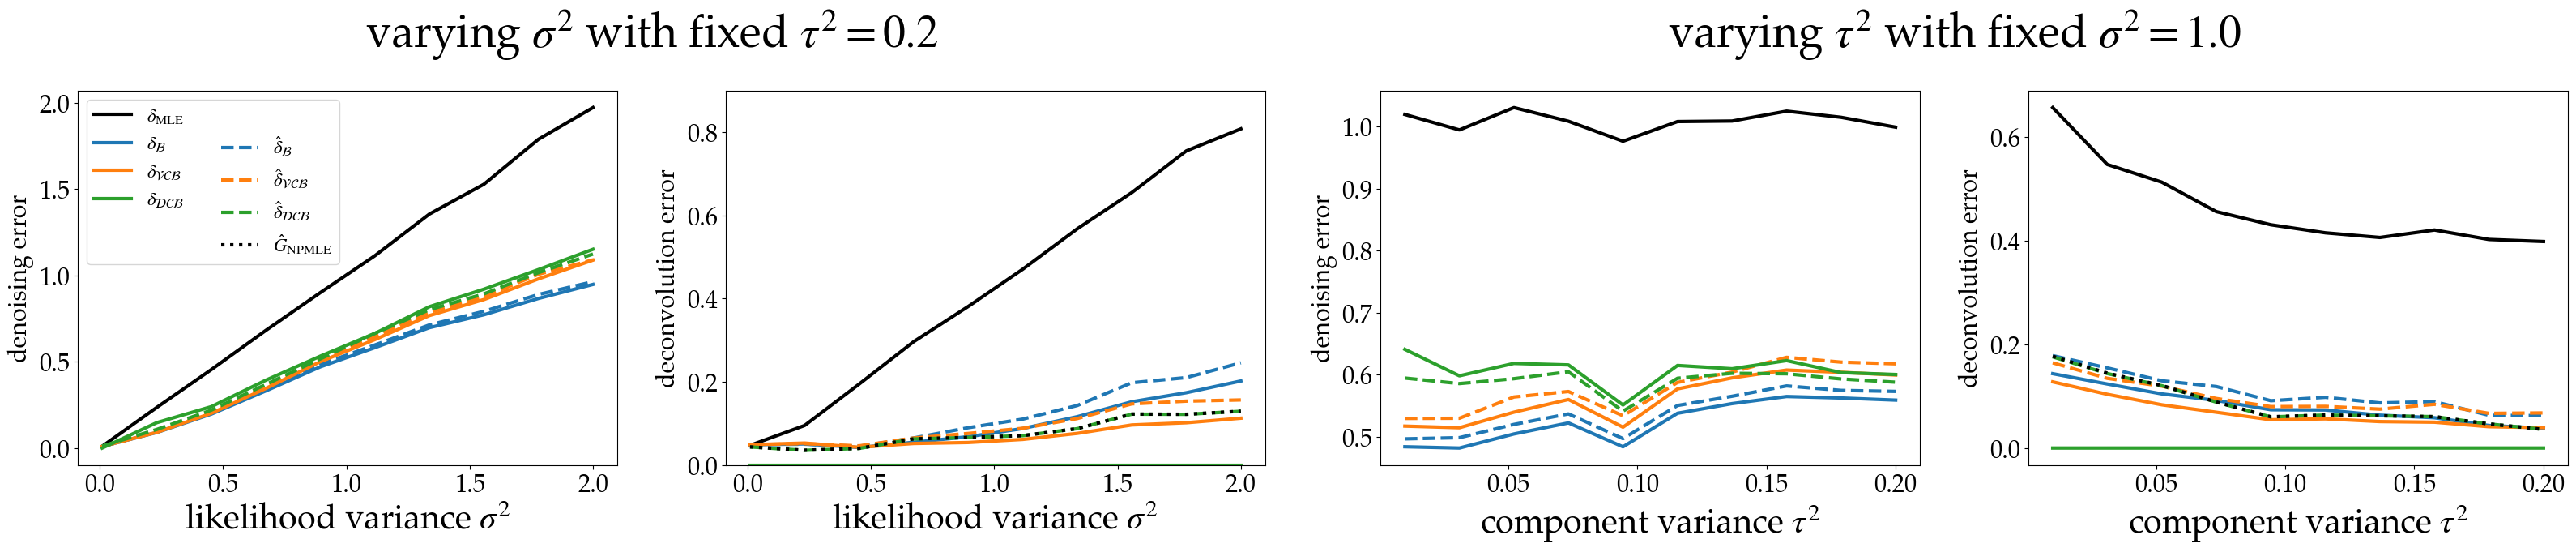

In [10]:
fig = plt.figure(figsize=(35,6))
subfigs = fig.subfigures(1, 2, wspace=-0.15)

subfigs[0].suptitle('varying $\\sigma^2$ with fixed $\\tau^2=0.2$', fontsize=40, weight='bold', y=1.05)
axs_left = subfigs[0].subplots(1, 2)
subfigs[1].suptitle('varying $\\tau^2$ with fixed $\\sigma^2=1.0$', fontsize=40, weight='bold', y=1.05)
axs_right = subfigs[1].subplots(1, 2)
ax = list(axs_left) + list(axs_right)

denoisers_latex = ['$\\delta_{\\mathrm{MLE}}$',
                   '$\\delta_{\\mathcal{B}}$','$\\hat{\\delta}_{\\mathcal{B}}$',
                   '$\\delta_{\\mathcal{VCB}}$','$\\hat{\\delta}_{\\mathcal{VCB}}$',
                   '$\\delta_{\\mathcal{DCB}}$','$\\hat{\\delta}_{\\mathcal{DCB}}$']
ghat_color, ghat_style, ghat_latex = 'black', 'dotted', '$\\hat{G}_{\\mathrm{NPMLE}}$'

for r in range(7):
    axs_left[0].plot(sigma2s, risks_sigma2_mean[r,:], linewidth=3,
               color=colors[r], linestyle=styles[r], label=denoisers_latex[r])
axs_left[0].set_ylabel('denoising error')
axs_left[0].set_xlabel('likelihood variance $\\sigma^2$', fontsize=30)

for r in range(7):
    axs_left[1].plot(sigma2s, dists_sigma2_mean[r,:], linewidth=3,
               color=colors[r], linestyle=styles[r], label=denoisers_latex[r])
axs_left[1].plot(sigma2s, dists_sigma2_mean[7,:], linewidth=3,
           color=ghat_color, linestyle=ghat_style, label=ghat_latex)
axs_left[1].set_ylabel('deconvolution error')
axs_left[1].set_xlabel('likelihood variance $\\sigma^2$', fontsize=30)
axs_left[1].set_ylim([0., 0.9])

# tau2
for r in range(7):
    axs_right[0].plot(tau2s, risks_tau2_mean[r,:], linewidth=3,
               color=colors[r], linestyle=styles[r], label=denoisers_latex[r])
axs_right[0].set_ylabel('denoising error')
axs_right[0].set_xlabel('component variance $\\tau^2$', fontsize=30)

for r in range(7):
    axs_right[1].plot(tau2s, dists_tau2_mean[r,:], linewidth=3,
               color=colors[r], linestyle=styles[r], label=denoisers_latex[r])
axs_right[1].plot(tau2s, dists_tau2_mean[7,:], linewidth=3,
           color=ghat_color, linestyle=ghat_style, label=ghat_latex)
axs_right[1].set_ylabel('deconvolution error')
axs_right[1].set_xlabel('component variance $\\tau^2$', fontsize=30)

from matplotlib.lines import Line2D
def leg_handle(color, style):
    return Line2D([0],[0], color=color, linestyle=style, linewidth=3)
blank = Line2D([0],[0], color='none')
handles = [leg_handle('black','solid'), leg_handle('C0','solid'), leg_handle('C1','solid'), leg_handle('C2','solid'), blank,
           blank, leg_handle('C0','dashed'), leg_handle('C1','dashed'), leg_handle('C2','dashed'), leg_handle(ghat_color,ghat_style)]
labels = [denoisers_latex[0], denoisers_latex[1], denoisers_latex[3], denoisers_latex[5], ' ',
          ' ', denoisers_latex[2], denoisers_latex[4], denoisers_latex[6], ghat_latex]
legend_fontsize = 0.75 * plt.rcParams['font.size']  # <-- change 0.75 to resize the legend
axs_left[0].legend(handles, labels, ncol=2, loc='upper left', fontsize=legend_fontsize)

plt.savefig('figs/sim_1d.pdf', bbox_inches='tight', pad_inches=0.3)
plt.savefig('figs/sim_1d.png', bbox_inches='tight', pad_inches=0.3)

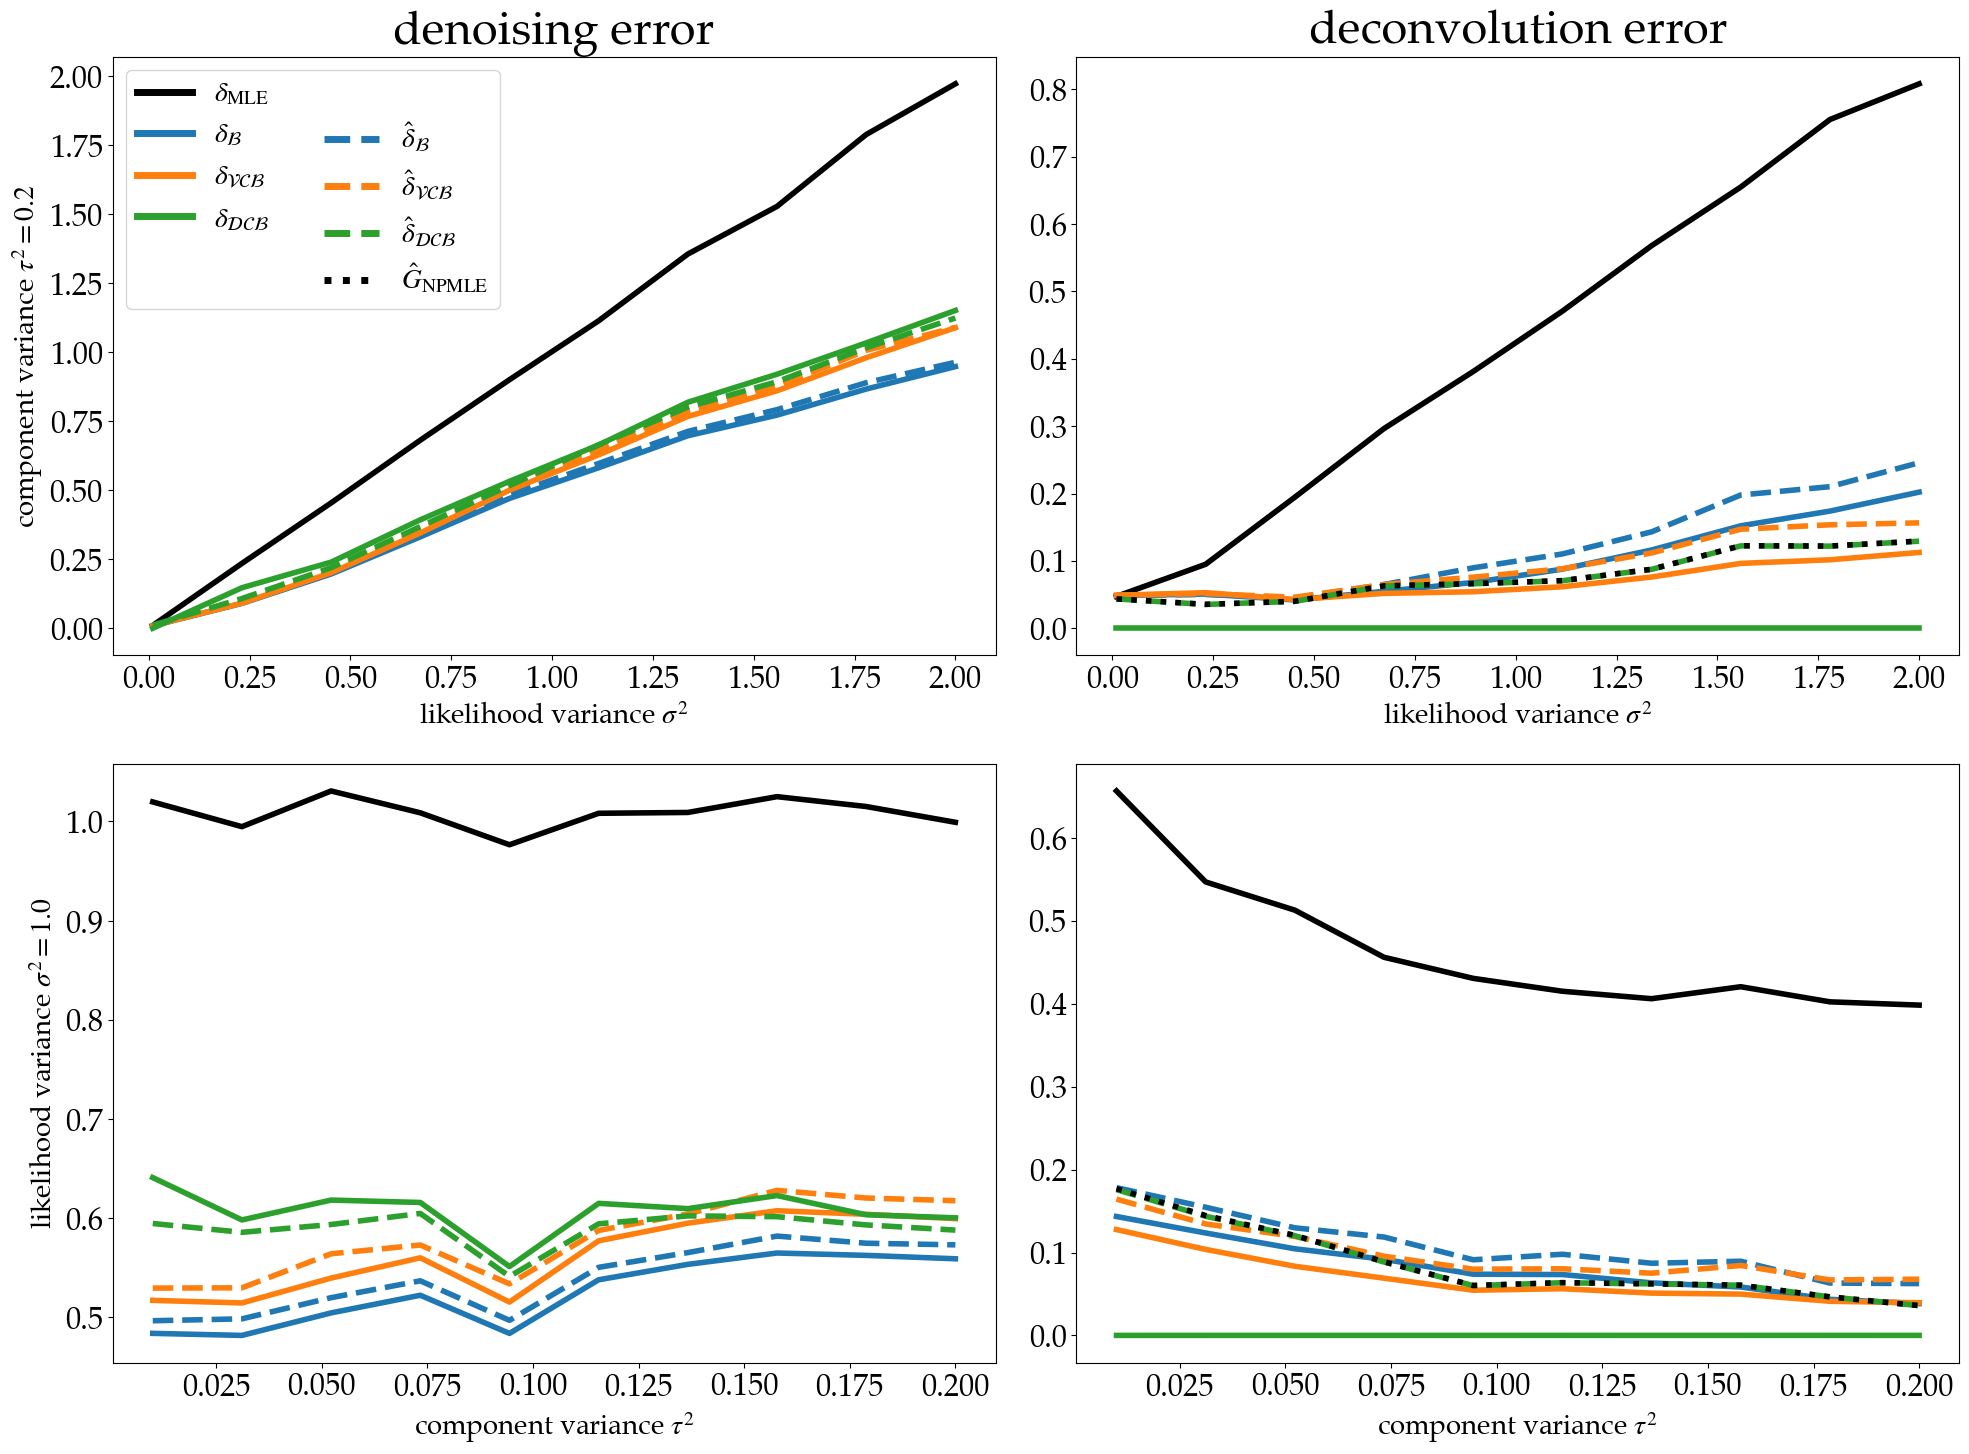

In [39]:
fig, ax = plt.subplots(2, 2, figsize=(20, 15))

denoisers_latex = ['$\\delta_{\\mathrm{MLE}}$',
                   '$\\delta_{\\mathcal{B}}$','$\\hat{\\delta}_{\\mathcal{B}}$',
                   '$\\delta_{\\mathcal{VCB}}$','$\\hat{\\delta}_{\\mathcal{VCB}}$',
                   '$\\delta_{\\mathcal{DCB}}$','$\\hat{\\delta}_{\\mathcal{DCB}}$']
ghat_color, ghat_style, ghat_latex = 'black', 'dotted', '$\\hat{G}_{\\mathrm{NPMLE}}$'

# top row: varying sigma^2
for r in range(7):
    ax[0,0].plot(sigma2s, risks_sigma2_mean[r,:], linewidth=4,
               color=colors[r], linestyle=styles[r], label=denoisers_latex[r])
ax[0,0].set_title('denoising error', fontsize=34, weight='bold')
ax[0,0].set_ylabel('component variance $\\tau^2=0.2$', fontsize=20)
ax[0,0].set_xlabel('likelihood variance $\\sigma^2$', fontsize=20)

for r in range(7):
    ax[0,1].plot(sigma2s, dists_sigma2_mean[r,:], linewidth=4,
               color=colors[r], linestyle=styles[r], label=denoisers_latex[r])
ax[0,1].plot(sigma2s, dists_sigma2_mean[7,:], linewidth=4,
           color=ghat_color, linestyle=ghat_style, label=ghat_latex)
ax[0,1].set_title('deconvolution error', fontsize=34, weight='bold')
ax[0,1].set_xlabel('likelihood variance $\\sigma^2$', fontsize=20)

# bottom row: varying tau^2
for r in range(7):
    ax[1,0].plot(tau2s, risks_tau2_mean[r,:], linewidth=4,
               color=colors[r], linestyle=styles[r], label=denoisers_latex[r])
ax[1,0].set_ylabel('likelihood variance $\\sigma^2=1.0$', fontsize=20)
ax[1,0].set_xlabel('component variance $\\tau^2$', fontsize=20)

for r in range(7):
    ax[1,1].plot(tau2s, dists_tau2_mean[r,:], linewidth=4,
               color=colors[r], linestyle=styles[r], label=denoisers_latex[r])
ax[1,1].plot(tau2s, dists_tau2_mean[7,:], linewidth=4,
           color=ghat_color, linestyle=ghat_style, label=ghat_latex)
ax[1,1].set_xlabel('component variance $\\tau^2$', fontsize=20)

from matplotlib.lines import Line2D
def leg_handle(color, style):
    return Line2D([0],[0], color=color, linestyle=style, linewidth=5)
blank = Line2D([0],[0], color='none')
handles = [leg_handle('black','solid'), leg_handle('C0','solid'), leg_handle('C1','solid'), leg_handle('C2','solid'), blank,
           blank, leg_handle('C0','dashed'), leg_handle('C1','dashed'), leg_handle('C2','dashed'), leg_handle(ghat_color,ghat_style)]
labels = [denoisers_latex[0], denoisers_latex[1], denoisers_latex[3], denoisers_latex[5], ' ',
          ' ', denoisers_latex[2], denoisers_latex[4], denoisers_latex[6], ghat_latex]
legend_fontsize = 0.9 * plt.rcParams['font.size']
ax[0,0].legend(handles, labels, ncol=2, loc='upper left', fontsize=legend_fontsize)

plt.tight_layout()
plt.savefig('figs/sim_1d.pdf', bbox_inches='tight', pad_inches=0.3)
plt.savefig('figs/sim_1d.png', bbox_inches='tight', pad_inches=0.3)